## 📌 Project Objective

The objective of this project is to detect fraudulent credit card transactions using machine learning techniques.

This is a **binary classification problem** where:
- **0 → Legitimate transaction**
- **1 → Fraudulent transaction**

Since fraud cases are extremely rare, the dataset is **highly imbalanced**.  
Therefore, evaluation metrics such as **Recall**, **ROC-AUC**, and **Confusion Matrix** are prioritized over accuracy.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## 📂 Loading the Dataset

The dataset contains anonymized credit card transactions.  
Features **V1–V28** are PCA-transformed for confidentiality.

Additional features:
- `Time`
- `Amount`
- `Class` (Target variable)


In [2]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.shape)

(284807, 31)


## 🧾 Dataset Structure and Data Types

This step helps us understand:
- Total number of records
- Data types of each feature
- Presence of any missing values


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## ⚖️ Class Distribution and Data Imbalance

Fraudulent transactions are extremely rare compared to legitimate ones.  
This severe imbalance makes the problem challenging and requires special handling techniques.


In [5]:
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

## ✂️ Feature–Target Separation and Train–Test Split

The dataset is divided into:
- Features (X)
- Target (y)

An 80–20 stratified split is performed to preserve class distribution in both sets.


In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)


(227845, 30)
(56962, 30)


## 📏 Feature Scaling using Standardization

StandardScaler is applied to normalize the feature values so that all features contribute equally to model training.


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 🤖 Baseline Model: Logistic Regression

Logistic Regression is used as the baseline model to understand how a simple linear classifier performs on the imbalanced dataset.


In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 📊 Evaluation of Logistic Regression Model

The model is evaluated using:
- Classification Report
- ROC-AUC Score
- Confusion Matrix


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9605494455801453


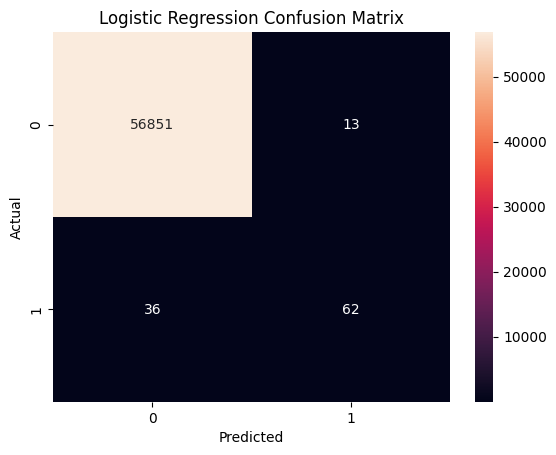

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 🧪 Handling Class Imbalance using SMOTE

SMOTE (Synthetic Minority Oversampling Technique) is applied to artificially generate fraud samples in the training data, balancing the dataset.


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train) 

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())


Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


## Logistic Regression Training on SMOTE-Balanced Data


In [11]:
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 🔁 Logistic Regression after Applying SMOTE

The same Logistic Regression model is retrained on the balanced dataset to observe performance improvement.


Logistic Regression with SMOTE
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9708434302252134


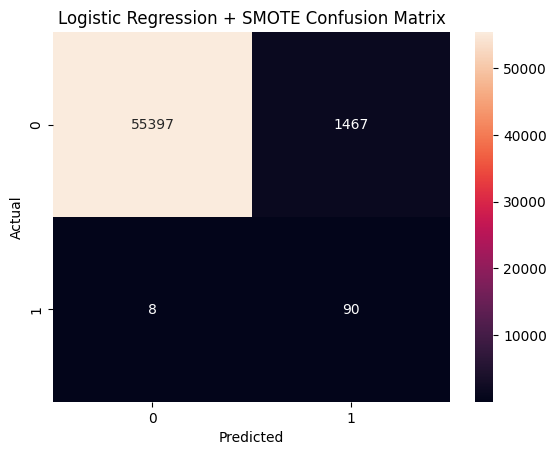

In [12]:
y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression with SMOTE")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d')
plt.title("Logistic Regression + SMOTE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Random Forest Model on Imbalanced Data


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluation of Random Forest Model (Without SMOTE)




Random Forest, a tree-based ensemble model, is trained on the original imbalanced data to compare its robustness against Logistic Regression.


Random Forest (No SMOTE)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9630272515590367


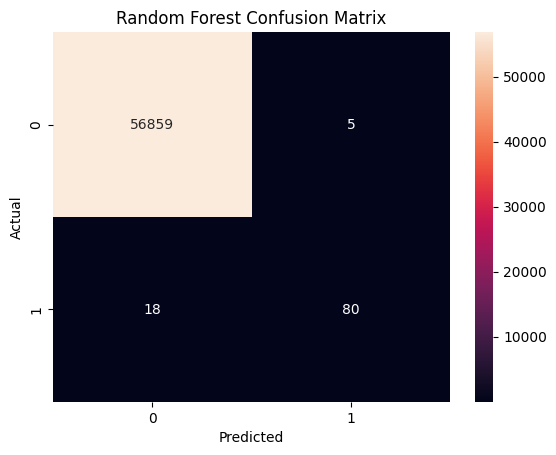

In [14]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("Random Forest (No SMOTE)")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 🌲 Random Forest with SMOTE

Random Forest is retrained on the SMOTE-balanced dataset to improve fraud detection capability.


In [15]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Random Forest + SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9684455679429904


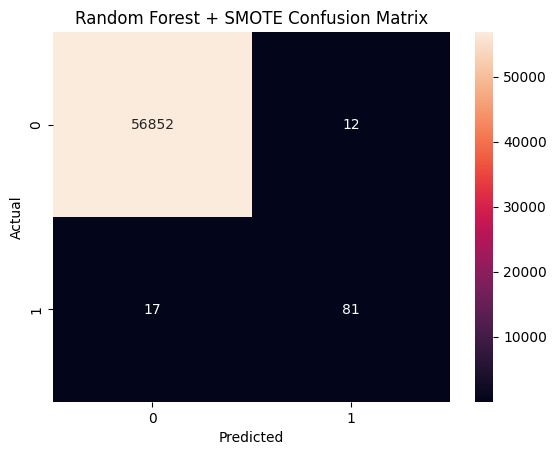

In [16]:
y_pred_rf_smote = rf_smote.predict(X_test_scaled)
y_prob_rf_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]

print("Random Forest + SMOTE")
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))

sns.heatmap(confusion_matrix(y_test, y_pred_rf_smote), annot=True, fmt='d')
plt.title("Random Forest + SMOTE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## ⚡ XGBoost Model Training

XGBoost, a gradient boosting algorithm, is trained on the balanced dataset for high-performance classification.


In [17]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

XGBoost + SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.85      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9799832109264641


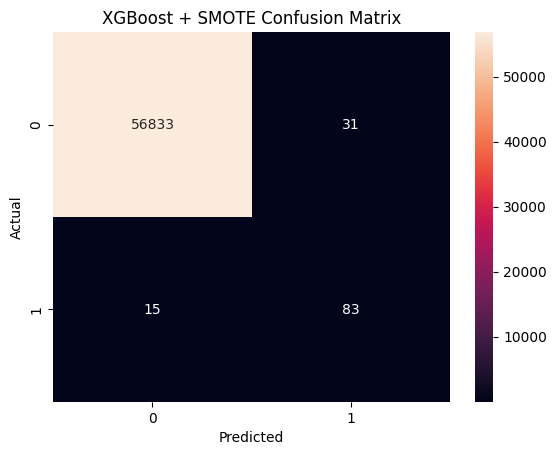

In [18]:
## Evaluation of XGBoost Model (With SMOTE)

# Generate predictions
y_pred_xgb = xgb_smote.predict(X_test_scaled)
y_prob_xgb = xgb_smote.predict_proba(X_test_scaled)[:, 1]

print("XGBoost + SMOTE")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("XGBoost + SMOTE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
## Cross-Validation using Stratified K-Fold (XGBoost)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

# Define pipeline with scaling + SMOTE + XGBoost
pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform Cross-Validation on ORIGINAL training data
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation ROC-AUC Scores: [0.99227461 0.97564383 0.95948254 0.98010148 0.97679946]
Mean ROC-AUC: 0.9768603851957274
Standard Deviation: 0.010503105447125214


## 🎛 Hyperparameter Tuning using RandomizedSearchCV (XGBoost)

In [20]:


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define parameter distributions
param_dist = {
    'xgb__n_estimators': randint(100, 400),
    'xgb__max_depth': randint(3, 10),
    'xgb__learning_rate': uniform(0.01, 0.3),
    'xgb__subsample': uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.6, 0.4)
}

# Create pipeline (scaler + SMOTE + XGB)
pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,               # keep reasonable
    scoring='roc_auc',
    cv=3,                    # 3-fold for tuning
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit on original training data
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best ROC-AUC:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'xgb__colsample_bytree': np.float64(0.9140703845572055), 'xgb__learning_rate': np.float64(0.06990213464750791), 'xgb__max_depth': 9, 'xgb__n_estimators': 343, 'xgb__subsample': np.float64(0.836965827544817)}
Best ROC-AUC: 0.9827556081803327


## 🚀 Train Final Tuned XGBoost Model

Tuned XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.87      0.82        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9789874587989388


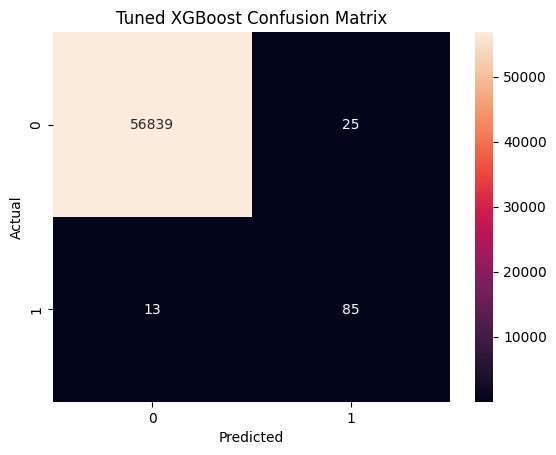

In [21]:


# Extract best XGBoost parameters
best_params = random_search.best_params_

# Remove pipeline prefixes
final_xgb = XGBClassifier(
    n_estimators=best_params['xgb__n_estimators'],
    max_depth=best_params['xgb__max_depth'],
    learning_rate=best_params['xgb__learning_rate'],
    subsample=best_params['xgb__subsample'],
    colsample_bytree=best_params['xgb__colsample_bytree'],
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train on SMOTE-balanced data
final_xgb.fit(X_train_smote, y_train_smote)

# Evaluate on test set
y_pred_final_xgb = final_xgb.predict(X_test_scaled)
y_prob_final_xgb = final_xgb.predict_proba(X_test_scaled)[:, 1]

print("Tuned XGBoost")
print(classification_report(y_test, y_pred_final_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final_xgb))

sns.heatmap(confusion_matrix(y_test, y_pred_final_xgb), annot=True, fmt='d')
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
from sklearn.ensemble import VotingClassifier


## 🧩 Ensemble Learning using Voting Classifier

The three models:
- Logistic Regression
- Random Forest
- XGBoost

are combined using **Soft Voting**, where prediction probabilities are averaged to produce a final decision.


Voting Classifier (With Tuned XGBoost)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9709374605216313


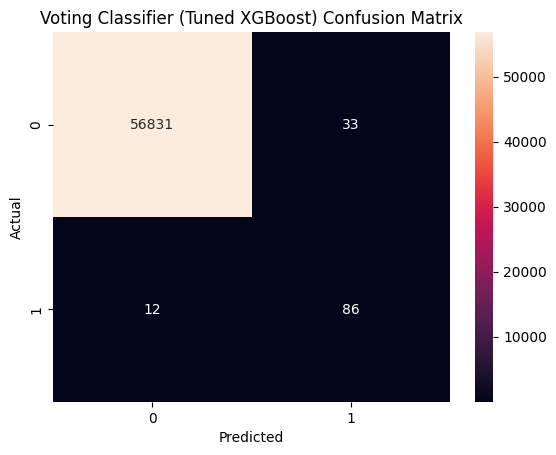

In [23]:
## 🧩 Rebuild Voting Ensemble using Tuned XGBoost

from sklearn.ensemble import VotingClassifier

# Create new voting model
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_smote),
        ('rf', rf_smote),
        ('xgb', final_xgb)  # <-- tuned model
    ],
    voting='soft'
)

# Train on SMOTE-balanced data
voting_model.fit(X_train_smote, y_train_smote)

# Evaluate on test data
y_pred_vote = voting_model.predict(X_test_scaled)
y_prob_vote = voting_model.predict_proba(X_test_scaled)[:, 1]

print("Voting Classifier (With Tuned XGBoost)")
print(classification_report(y_test, y_pred_vote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_vote))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_vote), annot=True, fmt='d')
plt.title("Voting Classifier (Tuned XGBoost) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 📊 Comparative Performance Table

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect metrics
models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Random Forest + SMOTE": (y_pred_rf_smote, y_prob_rf_smote),
    "Tuned XGBoost": (y_pred_final_xgb, y_prob_final_xgb),
    "Voting (Tuned XGB)": (y_pred_vote, y_prob_vote)
}

results = []

for name, (y_pred, y_prob) in models.items():
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

performance_df = pd.DataFrame(results)

performance_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.826667,0.632653,0.716763,0.960549
1,Random Forest + SMOTE,0.870968,0.826531,0.848168,0.968446
2,Tuned XGBoost,0.772727,0.867347,0.817308,0.978987
3,Voting (Tuned XGB),0.722689,0.877551,0.792627,0.970937


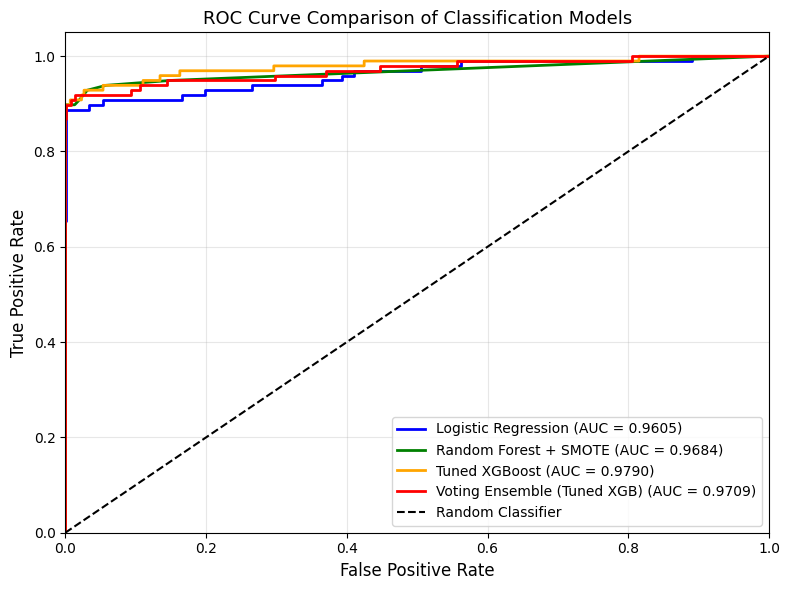

✅ ROC curve saved as roc_curve_comparison.png


In [25]:
## 📈 ROC Curve Comparison of All Models

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# All models with their predicted probabilities
models_roc = {
    "Logistic Regression": y_prob_lr,
    "Random Forest + SMOTE": y_prob_rf_smote,
    "Tuned XGBoost": y_prob_final_xgb,
    "Voting Ensemble (Tuned XGB)": y_prob_vote
}

# Colors for each model line
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(8, 6))

for (name, y_prob), color in zip(models_roc.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

# Diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], color='black', lw=1.5,
         linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison of Classification Models', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save as high resolution for paper
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curve saved as roc_curve_comparison.png")

## 🔍 SHAP Explainability for Tuned XGBoost

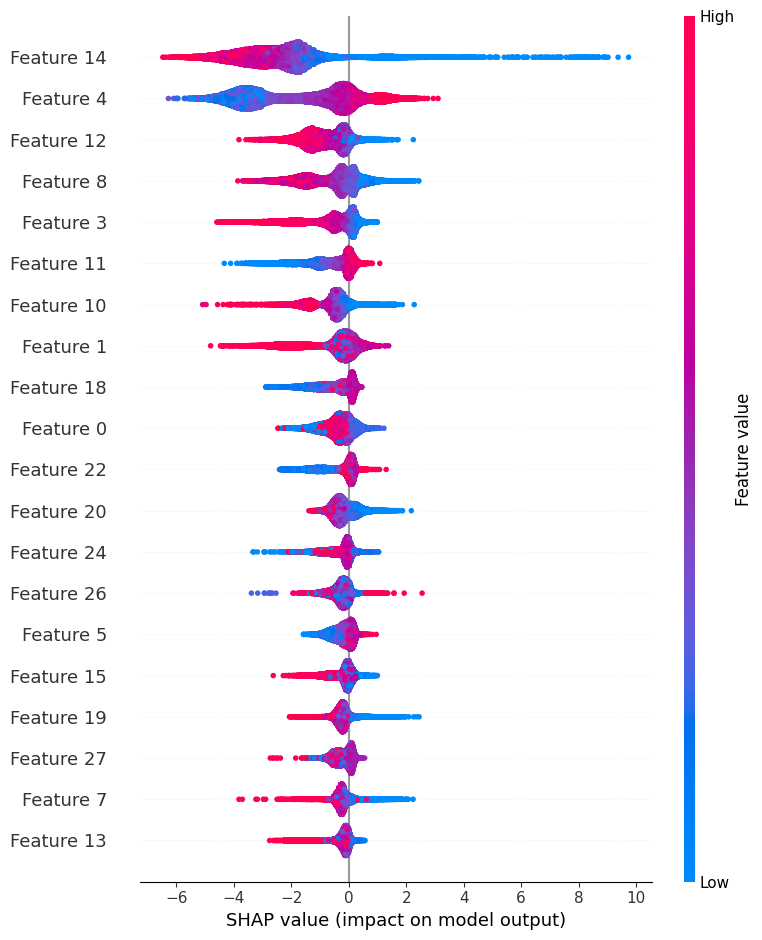

In [26]:
import shap

# Initialize JS visualization (for notebooks)
shap.initjs()

# Create TreeExplainer
explainer = shap.TreeExplainer(final_xgb)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test_scaled)

# Summary Plot (Global Feature Importance)
shap.summary_plot(shap_values, X_test_scaled)

## 💾 Model Serialization using Pickle

The trained Voting Classifier along with the StandardScaler is saved into a file named `fraud_model.pkl`.

This allows the model to be deployed without retraining.


In [27]:
import pickle

model_package = {
    "model": voting_model,
    "scaler": scaler
}

with open("../fraud_model.pkl", "wb") as f:
    pickle.dump(model_package, f)

print("✅ fraud_model.pkl saved successfully")


✅ fraud_model.pkl saved successfully


In [28]:
## 📊 Scenario Evaluation 1: Different Train/Test Splits

from sklearn.metrics import roc_auc_score, recall_score, f1_score, precision_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

split_results = []

for test_size in [0.10, 0.20, 0.30]:
    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Scale
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    # SMOTE
    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_sc, y_tr)

    # Train models
    lr_ = LogisticRegression(max_iter=1000)
    lr_.fit(X_tr_sm, y_tr_sm)

    rf_ = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_.fit(X_tr_sm, y_tr_sm)

    xgb_ = XGBClassifier(n_estimators=100, random_state=42,
                          use_label_encoder=False, eval_metric='logloss')
    xgb_.fit(X_tr_sm, y_tr_sm)

    vote_ = VotingClassifier(
        estimators=[('lr', lr_), ('rf', rf_), ('xgb', xgb_)],
        voting='soft'
    )
    vote_.fit(X_tr_sm, y_tr_sm)

    # Evaluate Voting Ensemble
    y_pred_ = vote_.predict(X_te_sc)
    y_prob_ = vote_.predict_proba(X_te_sc)[:, 1]

    split_results.append({
        "Split (Train/Test)": f"{int((1-test_size)*100)}/{int(test_size*100)}",
        "Precision": round(precision_score(y_te, y_pred_), 4),
        "Recall": round(recall_score(y_te, y_pred_), 4),
        "F1-Score": round(f1_score(y_te, y_pred_), 4),
        "ROC-AUC": round(roc_auc_score(y_te, y_prob_), 4)
    })

split_df = pd.DataFrame(split_results)
print("Scenario 1: Different Train/Test Splits (Voting Ensemble)")
print(split_df.to_string(index=False))


## 📊 Scenario Evaluation 2: With SMOTE vs Without SMOTE

smote_results = []

for use_smote in [False, True]:
    # Use original 80/20 split
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    if use_smote:
        sm = SMOTE(random_state=42)
        X_tr_f, y_tr_f = sm.fit_resample(X_tr_sc, y_train)
        label = "With SMOTE"
    else:
        X_tr_f, y_tr_f = X_tr_sc, y_train
        label = "Without SMOTE"

    # Train Voting Ensemble
    lr_ = LogisticRegression(max_iter=1000)
    lr_.fit(X_tr_f, y_tr_f)

    rf_ = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_.fit(X_tr_f, y_tr_f)

    xgb_ = XGBClassifier(n_estimators=100, random_state=42,
                          use_label_encoder=False, eval_metric='logloss')
    xgb_.fit(X_tr_f, y_tr_f)

    vote_ = VotingClassifier(
        estimators=[('lr', lr_), ('rf', rf_), ('xgb', xgb_)],
        voting='soft'
    )
    vote_.fit(X_tr_f, y_tr_f)

    y_pred_ = vote_.predict(X_test_scaled)
    y_prob_ = vote_.predict_proba(X_test_scaled)[:, 1]

    smote_results.append({
        "Scenario": label,
        "Precision": round(precision_score(y_test, y_pred_), 4),
        "Recall": round(recall_score(y_test, y_pred_), 4),
        "F1-Score": round(f1_score(y_test, y_pred_), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob_), 4)
    })

smote_df = pd.DataFrame(smote_results)
print("\nScenario 2: With SMOTE vs Without SMOTE (Voting Ensemble)")
print(smote_df.to_string(index=False))


## 📊 Scenario Evaluation 3: Different Class Imbalance Ratios

imbalance_results = []

for fraud_ratio in [0.001, 0.005, 0.010]:
    # Subsample fraud cases to simulate different imbalance ratios
    df_legit = df[df['Class'] == 0]
    df_fraud = df[df['Class'] == 1]

    n_fraud = int(len(df_legit) * fraud_ratio)
    n_fraud = min(n_fraud, len(df_fraud))  # can't exceed actual fraud count

    df_sample = pd.concat([
        df_legit,
        df_fraud.sample(n=n_fraud, random_state=42)
    ]).sample(frac=1, random_state=42)

    X_s = df_sample.drop('Class', axis=1)
    y_s = df_sample['Class']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_s, y_s, test_size=0.2, random_state=42, stratify=y_s
    )

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_sc, y_tr)

    lr_ = LogisticRegression(max_iter=1000)
    lr_.fit(X_tr_sm, y_tr_sm)

    rf_ = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_.fit(X_tr_sm, y_tr_sm)

    xgb_ = XGBClassifier(n_estimators=100, random_state=42,
                          use_label_encoder=False, eval_metric='logloss')
    xgb_.fit(X_tr_sm, y_tr_sm)

    vote_ = VotingClassifier(
        estimators=[('lr', lr_), ('rf', rf_), ('xgb', xgb_)],
        voting='soft'
    )
    vote_.fit(X_tr_sm, y_tr_sm)

    y_pred_ = vote_.predict(X_te_sc)
    y_prob_ = vote_.predict_proba(X_te_sc)[:, 1]

    imbalance_results.append({
        "Fraud Ratio": f"{fraud_ratio*100:.1f}%",
        "Fraud Samples": n_fraud,
        "Precision": round(precision_score(y_te, y_pred_, zero_division=0), 4),
        "Recall": round(recall_score(y_te, y_pred_, zero_division=0), 4),
        "F1-Score": round(f1_score(y_te, y_pred_, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_te, y_prob_), 4)
    })

imbalance_df = pd.DataFrame(imbalance_results)
print("\nScenario 3: Different Class Imbalance Ratios (Voting Ensemble)")
print(imbalance_df.to_string(index=False))

Scenario 1: Different Train/Test Splits (Voting Ensemble)
Split (Train/Test)  Precision  Recall  F1-Score  ROC-AUC
             90/10     0.7333  0.8980    0.8073   0.9569
             80/20     0.7167  0.8776    0.7890   0.9710
             70/30     0.7126  0.8378    0.7702   0.9733

Scenario 2: With SMOTE vs Without SMOTE (Voting Ensemble)
     Scenario  Precision  Recall  F1-Score  ROC-AUC
Without SMOTE     0.9625  0.7857    0.8652   0.9743
   With SMOTE     0.7167  0.8776    0.7890   0.9710

Scenario 3: Different Class Imbalance Ratios (Voting Ensemble)
Fraud Ratio  Fraud Samples  Precision  Recall  F1-Score  ROC-AUC
       0.1%            284     0.7183  0.8947    0.7969   0.9790
       0.5%            492     0.8000  0.8571    0.8276   0.9853
       1.0%            492     0.8000  0.8571    0.8276   0.9853
